### Task 1: Potential problems in linear regression

**Issue 1: Correlation of Error Terms**
***

The issue with this is that linear models assume that error terms are not correlated, and because of this the models reported standard errors are likely to become artifically small if the errors are correlated. This is important as it will make the model seem much more precise or accurate than it actually is, leading to potentially inaccurate interpretations. This can be detected by plotting the data residuals as a function of x and seeing if there is tracking in the residuals.

A question that thought of while reading that you couldn’t answer from the text alone, and the answer you investigated
While reading I wondered what the method for detection would be with non-timeseries data, as they only covered that. I found that for grouped data it is common to plot the residuals seperately for each group and see if there is tracking. 

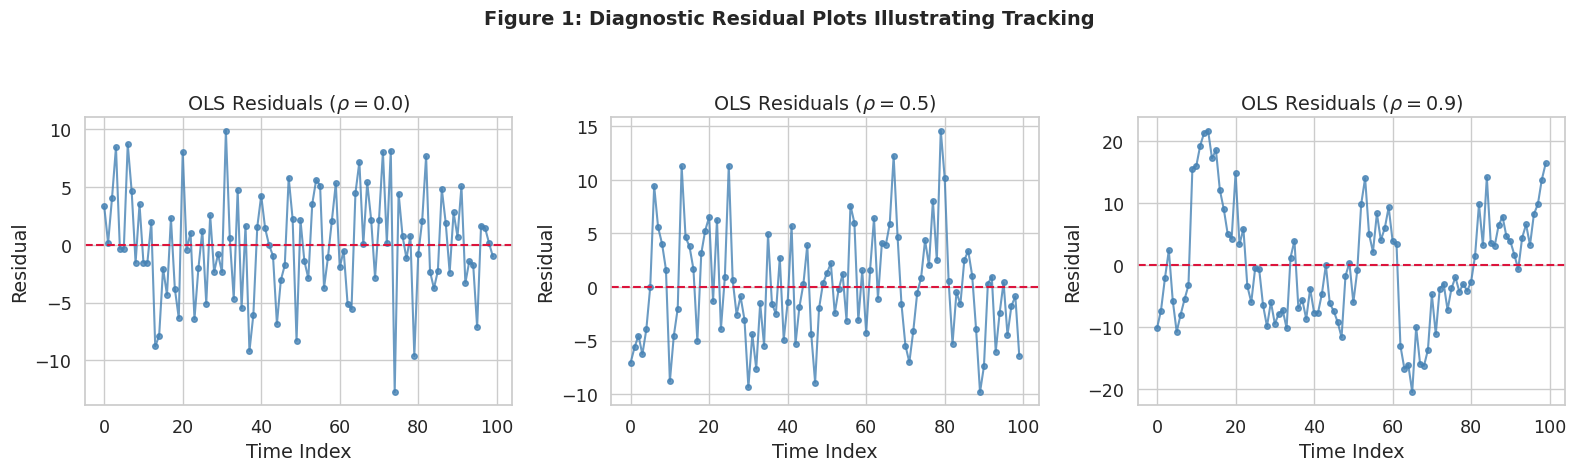

Table 1: Impact of Error Correlation on Inference for β₁ (Time Slope)
Correlation ($\rho$) Naive OLS SE HAC Corrected SE Naive OLS p-value HAC Corrected p-value
                 0.0       0.0158           0.0170        1.3586e-81            0.0000e+00
                 0.5       0.0178           0.0253        1.3527e-76            0.0000e+00
                 0.9       0.0323           0.0775        2.3440e-44            1.8110e-25


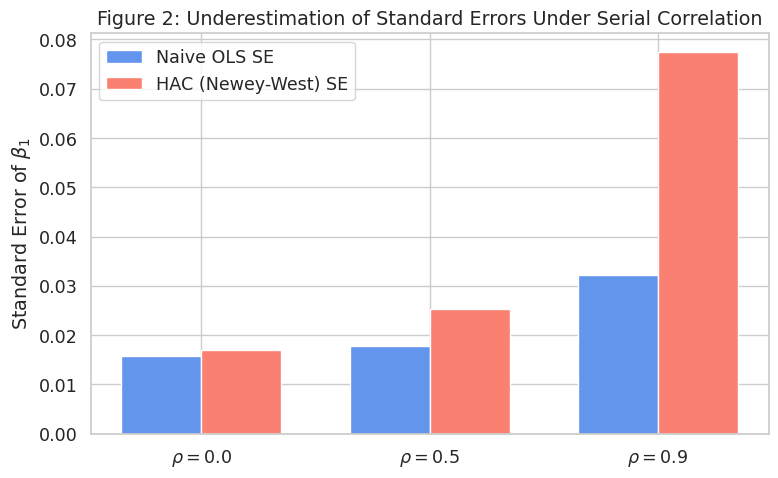

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Configure plotting environment for publication-quality figures
sns.set_theme(style="whitegrid", font_scale=1.15)
np.random.seed(42)

# =============================================================================
# 1. SYNTHETIC DATA GENERATION
# =============================================================================
n = 100
t = np.arange(n)
beta_0, beta_1 = 2.0, 1.0
sigma_u = 5.0  # Innovation standard deviation
rhos = [0.0, 0.5, 0.9]

def generate_ar1_errors(rho, n, sigma):
    """Generate AR(1) error terms: e_t = rho * e_{t-1} + u_t"""
    u = np.random.normal(0, sigma, n)
    e = np.zeros(n)
    e[0] = u[0]
    for i in range(1, n):
        e[i] = rho * e[i-1] + u[i]
    return e

# Create datasets for each correlation scenario
datasets = {}
for rho in rhos:
    errors = generate_ar1_errors(rho, n, sigma_u)
    y = beta_0 + beta_1 * t + errors
    datasets[rho] = pd.DataFrame({'time': t, 'response': y, 'true_errors': errors})

# =============================================================================
# 2. MODEL ESTIMATION (NAIVE OLS & CORRECTED HAC)
# =============================================================================
ols_results = {}
hac_results = {}

for rho in rhos:
    X = sm.add_constant(datasets[rho]['time'])
    y = datasets[rho]['response']
    
    # Naive OLS (assumes uncorrelated errors)
    ols_results[rho] = sm.OLS(y, X).fit()
    
    # OLS with HAC (Newey-West) standard errors to address serial correlation
    hac_results[rho] = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 10})

# =============================================================================
# 3. DIAGNOSTIC PLOTS: RESIDUALS VS. TIME
# =============================================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 4.5))
for i, rho in enumerate(rhos):
    res = ols_results[rho].resid
    axes1[i].plot(datasets[rho]['time'], res, marker='o', linestyle='-', 
                  markersize=4, color='steelblue', alpha=0.8)
    axes1[i].axhline(0, color='crimson', linestyle='--', linewidth=1.5)
    axes1[i].set_title(f'OLS Residuals ($\\rho = {rho}$)')
    axes1[i].set_xlabel('Time Index')
    axes1[i].set_ylabel('Residual')
fig1.suptitle('Figure 1: Diagnostic Residual Plots Illustrating Tracking', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# =============================================================================
# 4. QUANTIFYING THE CONSEQUENCES: STANDARD ERRORS & P-VALUES
# =============================================================================
# Extract statistics for the slope coefficient (time)
stats_df = pd.DataFrame({
    'Correlation ($\\rho$)': [f'{r}' for r in rhos],
    'Naive OLS SE': [ols_results[r].bse['time'] for r in rhos],
    'HAC Corrected SE': [hac_results[r].bse['time'] for r in rhos],
    'Naive OLS p-value': [ols_results[r].pvalues['time'] for r in rhos],
    'HAC Corrected p-value': [hac_results[r].pvalues['time'] for r in rhos]
})

print("Table 1: Impact of Error Correlation on Inference for β₁ (Time Slope)")
print(stats_df.to_string(index=False, formatters={
    'Correlation ($\\rho$)': '{:>5}'.format,
    'Naive OLS SE': '{:.4f}'.format,
    'HAC Corrected SE': '{:.4f}'.format,
    'Naive OLS p-value': '{:.4e}'.format,
    'HAC Corrected p-value': '{:.4e}'.format
}))

# Visualize SE inflation
fig2, ax2 = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(rhos))
width = 0.35
bars1 = ax2.bar(x_pos - width/2, stats_df['Naive OLS SE'], width, 
                label='Naive OLS SE', color='cornflowerblue')
bars2 = ax2.bar(x_pos + width/2, stats_df['HAC Corrected SE'], width, 
                label='HAC (Newey-West) SE', color='salmon')

ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'$\\rho={r}$' for r in rhos])
ax2.set_ylabel('Standard Error of $\\beta_1$')
ax2.set_title('Figure 2: Underestimation of Standard Errors Under Serial Correlation')
ax2.legend()
fig2.tight_layout()
plt.show()

# =============================================================================
# 5. ADDRESSING THE ISSUE: CORRECTED MODEL RESIDUALS (GLS/AR(1))
# =============================================================================
gls_results = {}
for rho in rhos:
    X = sm.add_constant(datasets[rho]['time'])
    y = datasets[rho]['response']
    
    # Estimate rho from OLS residuals for covariance structure
    e_ols = ols_results[rho].resid
    # Convert to NumPy arrays to prevent pandas index misalignment
    rho_hat = sm.OLS(e_ols.iloc[1:].to_numpy(), e_ols.iloc[:-1].to_numpy()).fit().params[0]
    
    # Construct AR(1) correlation matrix
    corr_mat = np.array([[rho_hat**abs(i-j) for j in range(n)] for i in range(n)])
    
    # Fit GLS with specified correlation structure
    gls_results[rho] = sm.GLS(y, X, sigma=corr_mat).fit()

Figure 1. shows the residuals over time between with three different levels of correlation between the predictor variables. We can see that as the correlation increses, the residuals begin to track more.

**Issue 2: Non-constant Variance of Error Terms**
***

Regression assumes that the variance of residuals is the same across all levels of predictor variables. Becuase calculations done with the regression model follow this assumption, the violation of it makes the outputs of the model unreliable. This can commonly be detected plotting the residuals against the fitted values and seeing if there is a funnel shape. If there is, then a common way to fix it is to transform the Y values. An example of this can be seen in the code section below.

a question that came up while reading that you couldn’t answer from the text alone, and the answer you investigated

While reading this rection I noticed that they only mentioned plotting against fitted values, which led me to wonder how we could detect if there was a predictor value causing the variance. I found that a common way of doing this is by plotting the residuals against each predictor seperately, similar to the above issue, and seeing if a funnel shape forms. Apparently this is primarily used to see which predictors may be driving the increase in variance.


Caption

**Issue 3: Collinearity**
***


a short paragraph explaining what the problem is, why it matters, and how to detect it (and how to address it, if applicable)


a question that came up while reading that you couldn’t answer from the text alone, and the answer you investigated



### Reflection
***